# So sánh  Adagrad và RMSprop
Dataset: housing.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# Đọc dữ liệu
data_path = '../datasets/housing.csv'
df = pd.read_csv(data_path)

# Tiền xử lý dữ liệu đơn giản
df = df.dropna() # Loại bỏ NaN
X = df.drop(columns=['median_house_value', 'ocean_proximity']).values
y = df['median_house_value'].values.reshape(-1, 1)

# Chuẩn hóa dữ liệu (Z-score normalization)
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
y = (y - np.mean(y)) / np.std(y)

# Thêm cột bias (1) vào X
X = np.c_[np.ones((X.shape[0], 1)), X]

m, n = X.shape
epochs = 1000
learning_rate = 0.1
epsilon = 1e-8

In [15]:
# ============================
# Adagrad
# ============================
theta_adagrad = np.zeros((n, 1))
G = np.zeros((n, 1))
adagrad_lr_history = []

for epoch in range(epochs):
    # Dự đoán và tính gradient
    predictions = X.dot(theta_adagrad)
    error = predictions - y
    gradient = (2/m) * X.T.dot(error)
    
    # Tích lũy bình phương gradient
    G += gradient ** 2
    
    # Tốc độ học hiệu dụng (trung bình các tham số)
    effective_lr = learning_rate / np.sqrt(G + epsilon)
    adagrad_lr_history.append(np.mean(effective_lr))
    
    # Cập nhật trọng số
    theta_adagrad -= effective_lr * gradient

In [16]:
# ============================
# RMSprop
# ============================
theta_rmsprop = np.zeros((n, 1))
v = np.zeros((n, 1))
gamma = 0.9
rmsprop_lr_history = []

for epoch in range(epochs):
    # Dự đoán và tính gradient
    predictions = X.dot(theta_rmsprop)
    error = predictions - y
    gradient = (2/m) * X.T.dot(error)
    
    # Trung bình di động theo cấp số nhân của bình phương gradient
    v = gamma * v + (1 - gamma) * (gradient ** 2)
    
    # Tốc độ học hiệu dụng
    effective_lr = learning_rate / np.sqrt(v + epsilon)
    rmsprop_lr_history.append(np.mean(effective_lr))
    
    # Cập nhật trọng số
    theta_rmsprop -= effective_lr * gradient

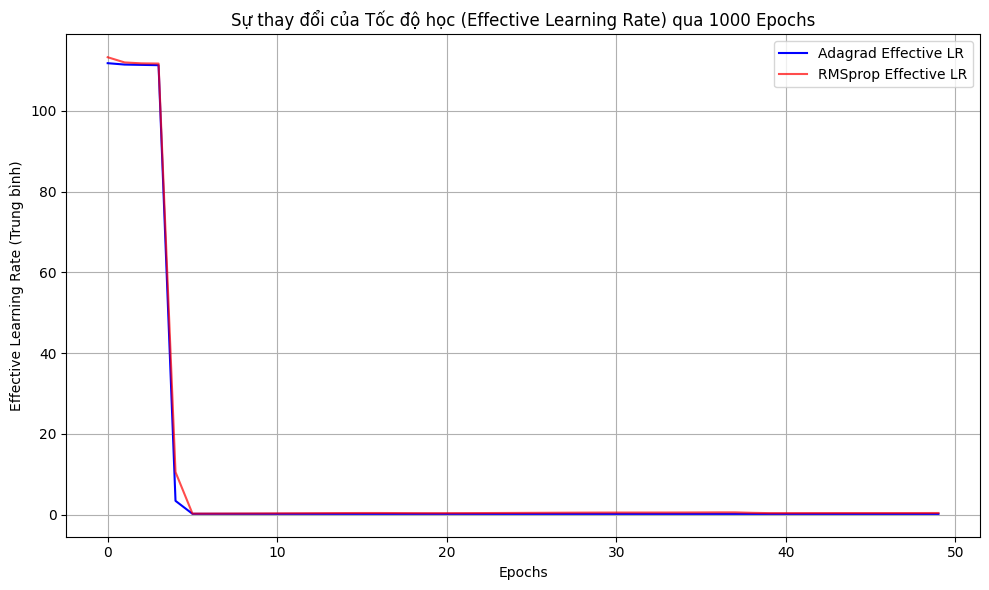

In [ ]:
# ============================
# Vẽ biểu đồ
# ============================
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), adagrad_lr_history, label='Adagrad', color='blue')
plt.plot(range(epochs), rmsprop_lr_history, label='RMSprop', color='red', alpha=0.7)
plt.title('Sự thay đổi của Tốc độ học (Effective Learning Rate) qua 1000 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Effective Learning Rate (Trung bình)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()